# Chunk-Based BERT with Label Attention
**Architecture**: PLM-ICD-inspired approach that processes full discharge notes via overlapping 512-token chunks through Bio_ClinicalBERT, then applies per-label attention to produce explainable predictions.

## 1. Config & GPU Check

In [ ]:
# Initializes execution environment.

import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from src.config import (
    DATA_DIR, MODEL_C_DIR, TRANSFORMER_MODEL, MAX_SEQ_LEN, SEED,
    MODEL_C_MAX_CHUNKS, MODEL_C_CHUNK_STRIDE,
    MODEL_C_FROZEN_LR, MODEL_C_FINETUNE_LR,
    MODEL_C_FROZEN_EPOCHS, MODEL_C_FINETUNE_EPOCHS,
    MODEL_C_BATCH_SIZE, MODEL_C_GRAD_ACCUM, MODEL_C_DROPOUT,
    USE_AMP,
)
from src.train import set_seed

set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
    print(f'CUDA: {torch.version.cuda}')
    print(f'fp16: ENABLED')
else:
    print('WARNING: No GPU — training will be extremely slow!')

print(f'\nModel C Config:')
print(f'  Max chunks:      {MODEL_C_MAX_CHUNKS}')
print(f'  Chunk stride:    {MODEL_C_CHUNK_STRIDE}')
print(f'  Batch size:      {MODEL_C_BATCH_SIZE}')
print(f'  Grad accum:      {MODEL_C_GRAD_ACCUM}')
print(f'  Effective batch: {MODEL_C_BATCH_SIZE * MODEL_C_GRAD_ACCUM}')
print(f'  Frozen epochs:   {MODEL_C_FROZEN_EPOCHS} (lr={MODEL_C_FROZEN_LR})')
print(f'  Finetune epochs: {MODEL_C_FINETUNE_EPOCHS} (lr={MODEL_C_FINETUNE_LR})')

GPU: NVIDIA L4 (23.7 GB)
CUDA: 12.8
fp16: ENABLED

Model C Config:
  Max chunks:      6
  Chunk stride:    256
  Batch size:      4
  Grad accum:      8
  Effective batch: 32
  Frozen epochs:   5 (lr=0.001)
  Finetune epochs: 3 (lr=2e-05)


## 2. Load Data & Labels

In [ ]:
# Loads training, validation, and test splits.

train_df, val_df, test_df = load_splits()
mlb = load_label_binarizer()
vocab = list(mlb.classes_)
NUM_LABELS = len(vocab)

Y_train = build_label_matrix(train_df, mlb)
Y_val   = build_label_matrix(val_df, mlb)
Y_test  = build_label_matrix(test_df, mlb)

print(f'Labels: {NUM_LABELS}')
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print(f'Y_train shape: {Y_train.shape}')
print(f'Label density: {Y_train.mean():.4f}')

/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00...
(warning truncated)


Labels: 50
Train: 85081  Val: 18371  Test: 18852
Y_train shape: (85081, 50)
Label density: 0.1016


/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00...
(warning truncated)


## 3. Compute Positive Class Weights

In [ ]:
# Computes positive class weights for rare labels.

from src.evaluate import compute_pos_weights

pos_weights = compute_pos_weights(Y_train, clamp_max=50.0)
pos_weight_tensor = torch.tensor(pos_weights)

print(f'Pos weights range: [{pos_weights.min():.1f}, {pos_weights.max():.1f}]')
print(f'Mean pos weight: {pos_weights.mean():.1f}')
print(f'\nTop 5 most weighted labels (rarest):')
for idx in np.argsort(pos_weights)[::-1][:5]:
    freq = Y_train[:, idx].sum()
    print(f'  {vocab[idx]:12s}  freq={freq:5.0f}  weight={pos_weights[idx]:.1f}')

Pos weights range: [1.8, 20.5]
Mean pos weight: 12.0

Top 5 most weighted labels (rarest):
  Y92230        freq= 3951  weight=20.5
  Z23           freq= 3992  weight=20.3
  J189          freq= 4055  weight=20.0
  Y92239        freq= 4166  weight=19.4
  J9601         freq= 4198  weight=19.3


## 4. Create Chunked Datasets & DataLoaders

In [ ]:
# Creates chunked datasets and data loaders.

from src.data import ChunkedICDDataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

train_ds = ChunkedICDDataset(train_df['clean_text'], Y_train, tokenizer=tokenizer)
val_ds   = ChunkedICDDataset(val_df['clean_text'],   Y_val,   tokenizer=tokenizer)
test_ds  = ChunkedICDDataset(test_df['clean_text'],  Y_test,  tokenizer=tokenizer)

train_loader = DataLoader(train_ds, batch_size=MODEL_C_BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=MODEL_C_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=MODEL_C_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}')

sample = train_ds[0]
print(f'\nSample shapes:')
print(f'  input_ids:      {sample["input_ids"].shape}')
print(f'  attention_mask: {sample["attention_mask"].shape}')
print(f'  chunk_count:    {sample["chunk_count"]}')
print(f'  labels:         {sample["labels"].shape}')

Train batches: 21271  Val batches: 4593  Test batches: 4713

Sample shapes:
  input_ids:      torch.Size([6, 512])
  attention_mask: torch.Size([6, 512])
  chunk_count:    6
  labels:         torch.Size([50])


## 5. Build Label Attention Classifier

In [ ]:
# Builds the model with label attention classifier.

from src.models import LabelAttentionClassifier

model = LabelAttentionClassifier(
    model_name=TRANSFORMER_MODEL,
    num_labels=NUM_LABELS,
    max_chunks=MODEL_C_MAX_CHUNKS,
    freeze_bert=True,
    dropout=MODEL_C_DROPOUT,
).to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen         = total_params - trainable

print(f'Total parameters:     {total_params:>12,}')
print(f'Trainable parameters: {trainable:>12,}  (attention + classifier)')
print(f'Frozen parameters:    {frozen:>12,}  (BERT)')
print(f'\nBERT: Frozen during Phase 1')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT...
(warning truncated)


Total parameters:      108,349,441
Trainable parameters:       39,169  (attention + classifier)
Frozen parameters:     108,310,272  (BERT)

BERT backbone: Frozen during Phase 1


## 6. Phase 1: Train with Frozen BERT

In [ ]:
# Trains the model with frozen BERT.

from src.train import train_model

print('='*60)
print('PHASE 1: Frozen BERT — training attention + classifier only')
print('='*60)

history_frozen = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=MODEL_C_DIR,
    lr=MODEL_C_FROZEN_LR,
    epochs=MODEL_C_FROZEN_EPOCHS,
    grad_accum=MODEL_C_GRAD_ACCUM,
    warmup_ratio=0.05,
    pos_weight=pos_weight_tensor,
    checkpoint_every=2000,
    is_chunked=True,
    device=device,
)

PHASE 1: Frozen BERT — training attention + classifier only
  Step 500/21271  loss=1.3268  GPU mem: 0.5GB
  Step 1000/21271  loss=1.2988  GPU mem: 0.5GB
  Step 1500/21271  loss=1.2809  GPU mem: 0.5GB
  Step 2000/21271  loss=1.2728  GPU mem: 0.5GB
  -> mid-epoch checkpoint saved
  Step 2500/21271  loss=1.2679  GPU mem: 0.5GB
  Step 3000/21271  loss=1.2590  GPU mem: 0.5GB
  Step 3500/21271  loss=1.2524  GPU mem: 0.5GB
  Step 4000/21271  loss=1.2460  GPU mem: 0.5GB
  -> mid-epoch checkpoint saved
  Step 4500/21271  loss=1.2372  GPU mem: 0.5GB
  Step 5000/21271  loss=1.2258  GPU mem: 0.5GB
  Step 5500/21271  loss=1.2129  GPU mem: 0.5GB
  Step 6000/21271  loss=1.2003  GPU mem: 0.5GB
  -> mid-epoch checkpoint saved
  Step 6500/21271  loss=1.1885  GPU mem: 0.5GB
  Step 7000/21271  loss=1.1757  GPU mem: 0.5GB
  Step 7500/21271  loss=1.1644  GPU mem: 0.5GB
  Step 8000/21271  loss=1.1535  GPU mem: 0.5GB
  -> mid-epoch checkpoint saved
  Step 8500/21271  loss=1.1423  GPU mem: 0.5GB
  Step 9000/21

## 7. Phase 2: Fine-tune Last 2 BERT Layers

In [7]:
# Reload best checkpoint from Phase 1
model.load_state_dict(torch.load(MODEL_C_DIR / 'best_model.pt', map_location=device))

# Unfreeze last 2 BERT layers
model.unfreeze_bert_layers(num_layers=2)

print('\n' + '='*60)
print('PHASE 2: Fine-tuning last 2 BERT layers + attention + classifier')
print('='*60)

history_finetune = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=MODEL_C_DIR,
    lr=MODEL_C_FINETUNE_LR,
    epochs=MODEL_C_FINETUNE_EPOCHS,
    grad_accum=MODEL_C_GRAD_ACCUM,
    warmup_ratio=0.1,
    pos_weight=pos_weight_tensor,
    checkpoint_every=2000,
    is_chunked=True,
    device=device,
)

Unfroze last 2 BERT layers. Trainable params: 14,805,505

PHASE 2: Fine-tuning last 2 BERT layers + attention + classifier
  Step 500/21271  loss=0.7856  GPU mem: 0.6GB
  Step 1000/21271  loss=0.7916  GPU mem: 0.6GB
  Step 1500/21271  loss=0.7916  GPU mem: 0.6GB
  Step 2000/21271  loss=0.7936  GPU mem: 0.6GB
  -> mid-epoch checkpoint saved
  Step 2500/21271  loss=0.7917  GPU mem: 0.6GB
  Step 3000/21271  loss=0.7951  GPU mem: 0.6GB
  Step 3500/21271  loss=0.7950  GPU mem: 0.6GB
  Step 4000/21271  loss=0.7961  GPU mem: 0.6GB
  -> mid-epoch checkpoint saved
  Step 4500/21271  loss=0.7969  GPU mem: 0.6GB
  Step 5000/21271  loss=0.7960  GPU mem: 0.6GB
  Step 5500/21271  loss=0.7956  GPU mem: 0.6GB
  Step 6000/21271  loss=0.7945  GPU mem: 0.6GB
  -> mid-epoch checkpoint saved
  Step 6500/21271  loss=0.7933  GPU mem: 0.6GB
  Step 7000/21271  loss=0.7938  GPU mem: 0.6GB
  Step 7500/21271  loss=0.7943  GPU mem: 0.6GB
  Step 8000/21271  loss=0.7938  GPU mem: 0.6GB
  -> mid-epoch checkpoint save

## 8. Training History Visualization

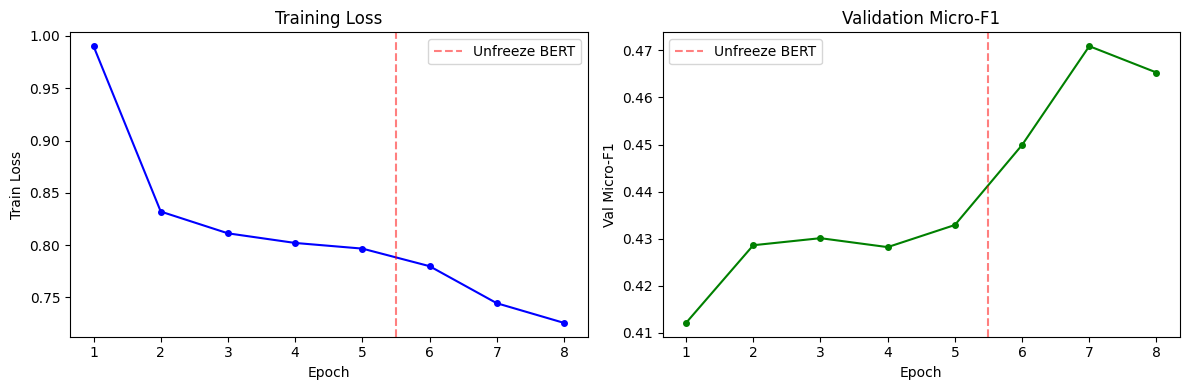

 epoch  train_loss  val_micro_f1
     1      0.9902        0.4121
     2      0.8321        0.4286
     3      0.8113        0.4301
     4      0.8021        0.4282
     5      0.7967        0.4329
     6      0.7799        0.4499
     7      0.7445        0.4709
     8      0.7257        0.4653


In [ ]:
# Plots training history.

import matplotlib.pyplot as plt

full_history = history_frozen + [
    {**h, 'epoch': h['epoch'] + MODEL_C_FROZEN_EPOCHS} for h in history_finetune
]
hist_df = pd.DataFrame(full_history)
hist_df.to_csv(MODEL_C_DIR / 'full_training_history.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(hist_df['epoch'], hist_df['train_loss'], 'b-o', markersize=4)
ax1.axvline(x=MODEL_C_FROZEN_EPOCHS + 0.5, color='red', linestyle='--', alpha=0.5, label='Unfreeze BERT')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss'); ax1.set_title('Training Loss')
ax1.legend()

# Val F1
ax2.plot(hist_df['epoch'], hist_df['val_micro_f1'], 'g-o', markersize=4)
ax2.axvline(x=MODEL_C_FROZEN_EPOCHS + 0.5, color='red', linestyle='--', alpha=0.5, label='Unfreeze BERT')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Micro-F1'); ax2.set_title('Validation Micro-F1')
ax2.legend()

plt.tight_layout()
plt.savefig(MODEL_C_DIR / 'training_curves.png', dpi=150)
plt.show()
print(hist_df.to_string(index=False))

## 9. Threshold Tuning & Test Evaluation

In [ ]:
# Finds the best classification threshold and evaluates model performance.

import json
from src.evaluate import tune_global_threshold, full_metrics
from src.train import evaluate_predictions

model.load_state_dict(torch.load(MODEL_C_DIR / 'best_model.pt', map_location=device))
model.eval()

print('Computing validation probabilities...')
_, P_val, Y_val_np = evaluate_predictions(
    model, val_loader, device=device, use_amp=USE_AMP, is_chunked=True,
)

best_t, best_vf1 = tune_global_threshold(P_val, Y_val_np)
print(f'Best threshold: {best_t:.3f}  val micro-F1: {best_vf1:.4f}')

print('\nComputing test probabilities...')
_, P_test, Y_test_np = evaluate_predictions(
    model, test_loader, device=device, use_amp=USE_AMP, is_chunked=True,
)

results = full_metrics(P_test, Y_test_np, best_t, 'Model C (Chunk+LabelAttn)')
print('\n=== Test Results ===')
for k, v in results.items():
    print(f'  {k:15s}: {v}')

with open(MODEL_C_DIR / 'test_results.json', 'w') as f:
    json.dump(results, f, indent=2)
np.save(MODEL_C_DIR / 'P_test.npy', P_test)
np.save(MODEL_C_DIR / 'P_val.npy', P_val)
print('\nResults and probabilities saved.')

Computing validation probabilities...
Best threshold: 0.625  val micro-F1: 0.5353

Computing test probabilities...

=== Test Results ===
  Model          : Model C (Chunk+LabelAttn)
  Threshold      : 0.625
  Micro-F1       : 0.5305
  Macro-F1       : 0.5
  Micro-Prec     : 0.4191
  Micro-Rec      : 0.7225
  Macro-AUPRC    : 0.5201
  Micro-AUROC    : 0.8938

Results and probabilities saved.


## 10. Head vs Tail Analysis

Bucket                          n   Avg F1
---------------------------------------------
head (>=500)                   50   0.5000
torso (100-499)                 0      nan
tail (<100)                     0      nan


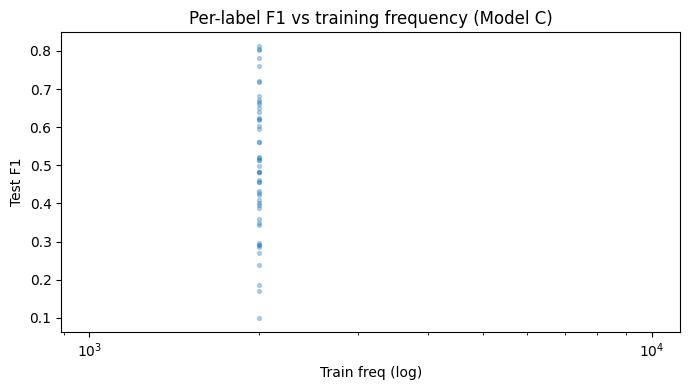

In [ ]:
# Analyzes the performance of the model across different label frequency buckets.

from sklearn.metrics import f1_score

preds_test = (P_test >= best_t).astype(int)
per_label_f1 = f1_score(Y_test_np, preds_test, average=None, zero_division=0)
per_label_freq = Y_train.sum(0)

label_df = pd.DataFrame({
    'icd_code':   vocab,
    'train_freq': per_label_freq,
    'test_f1':    per_label_f1,
}).sort_values('train_freq', ascending=False)

print(f'{"Bucket":25s}  {"n":>6}  {"Avg F1":>7}')
print('-' * 45)
for lo, hi, name in [(500, 1e9, 'head (>=500)'), (100, 499, 'torso (100-499)'), (0, 99, 'tail (<100)')]:
    s = label_df[(label_df['train_freq'] >= lo) & (label_df['train_freq'] <= hi)]
    print(f'{name:25s}  {len(s):6d}  {s["test_f1"].mean():7.4f}')

plt.figure(figsize=(7, 4))
plt.scatter(label_df['train_freq'].clip(upper=2000), label_df['test_f1'], alpha=0.3, s=8)
plt.xscale('log'); plt.xlabel('Train freq (log)'); plt.ylabel('Test F1')
plt.title('Per-label F1 vs training frequency (Model C)')
plt.tight_layout()
plt.savefig(MODEL_C_DIR / 'head_tail_f1.png', dpi=120)
plt.show()

## 11. Demo


In [ ]:
# Visualizes which words the label attention focuses on for each predicted code.

from src.explain import explain_prediction

SAMPLE_NOTE = """
Patient is a 72-year-old male with a history of type 2 diabetes mellitus, chronic kidney disease
stage 3, and hypertension who presented with shortness of breath and bilateral lower extremity
edema. Hospital course was notable for decompensated heart failure treated with IV furosemide.
Discharge diagnoses: acute on chronic systolic heart failure, type 2 diabetes mellitus,
hypertensive heart disease, CKD stage 3.
"""

explanations = explain_prediction(
    text=SAMPLE_NOTE,
    model=model,
    mlb=mlb,
    tokenizer=tokenizer,
    threshold=best_t,
    top_n_codes=10,
    top_k_tokens=10,
    device=device,
)

print(f'{"ICD-10 Code":15s}  {"Prob":>8}  {"Predicted":>10}  Top Evidence Tokens')
print('-' * 80)
for exp in explanations:
    top_words = ', '.join([f'{tok}({w:.3f})' for tok, w in exp['evidence'][:5]])
    marker = 'YES' if exp['predicted'] else '  -'
    print(f'{exp["code"]:15s}  {exp["probability"]:8.4f}  {marker:>10}  {top_words}')

ICD-10 Code          Prob   Predicted  Top Evidence Tokens
--------------------------------------------------------------------------------
E1122              0.9953         YES  diabetes(0.580), diabetes(0.243), kidney(0.034), ##tus(0.033), ##tus(0.008)
N183               0.9880         YES  ##k(0.560), kidney(0.197), disease(0.019), heart(0.018), diabetes(0.017)
I130               0.9731         YES  failure(0.308), heart(0.143), failure(0.105), ##k(0.100), kidney(0.076)
N400               0.9554         YES  male(0.782), hospital(0.036), patient(0.034), .(0.022), discharge(0.014)
Z794               0.9410         YES  type(0.491), type(0.205), diabetes(0.138), diabetes(0.048), ##lli(0.011)
I129               0.9190         YES  chronic(0.185), c(0.130), kidney(0.123), ##yper(0.104), chronic(0.069)
N179               0.9114         YES  failure(0.297), failure(0.153), heart(0.072), ##ness(0.060), kidney(0.036)
N189               0.8826         YES  chronic(0.145), chronic(0.140), kid

## 12. Compare All Three Models

In [ ]:
# Compares the performance of all three models.

from src.config import MODEL_A_DIR, MODEL_B_DIR

with open(MODEL_A_DIR / 'results.json') as f:
    res_a = json.load(f)
with open(MODEL_B_DIR / 'test_results.json') as f:
    res_b = json.load(f)

comparison = pd.DataFrame([
    {'Model': 'A: TF-IDF + SGD',
     'Micro-F1': res_a['test']['micro_f1'],
     'Macro-F1': res_a['test']['macro_f1'],
     'Micro-Prec': res_a['test']['micro_prec'],
     'Micro-Rec': res_a['test']['micro_rec'],
     'AUROC': res_a['test']['micro_auroc'],
     'Threshold': res_a['test']['threshold']},
    {'Model': 'B: ClinicalBERT (512-tok)',
     'Micro-F1': res_b['micro_f1'],
     'Macro-F1': res_b['macro_f1'],
     'Micro-Prec': res_b['micro_prec'],
     'Micro-Rec': res_b['micro_rec'],
     'AUROC': res_b['micro_auroc'],
     'Threshold': res_b['threshold']},
    {'Model': 'C: Chunk + Label Attn',
     'Micro-F1': results['Micro-F1'],
     'Macro-F1': results['Macro-F1'],
     'Micro-Prec': results['Micro-Prec'],
     'Micro-Rec': results['Micro-Rec'],
     'AUROC': results['Micro-AUROC'],
     'Threshold': results['Threshold']},
])

print('\n=== All Models Comparison (Test Set) ===')
print(comparison.to_string(index=False))
comparison.to_csv(MODEL_C_DIR / 'three_model_comparison.csv', index=False)


=== All Models Comparison (Test Set) ===
                    Model  Micro-F1  Macro-F1  Micro-Prec  Micro-Rec    AUROC  Threshold
          A: TF-IDF + SGD  0.595187  0.569617    0.494081   0.748319 0.925018      0.525
B: ClinicalBERT (512-tok)  0.524198  0.442893    0.524655   0.523742 0.868642      0.275
    C: Chunk + Label Attn  0.530500  0.500000    0.419100   0.722500 0.893800      0.625


## 13. Per-Label Confusion Matrix

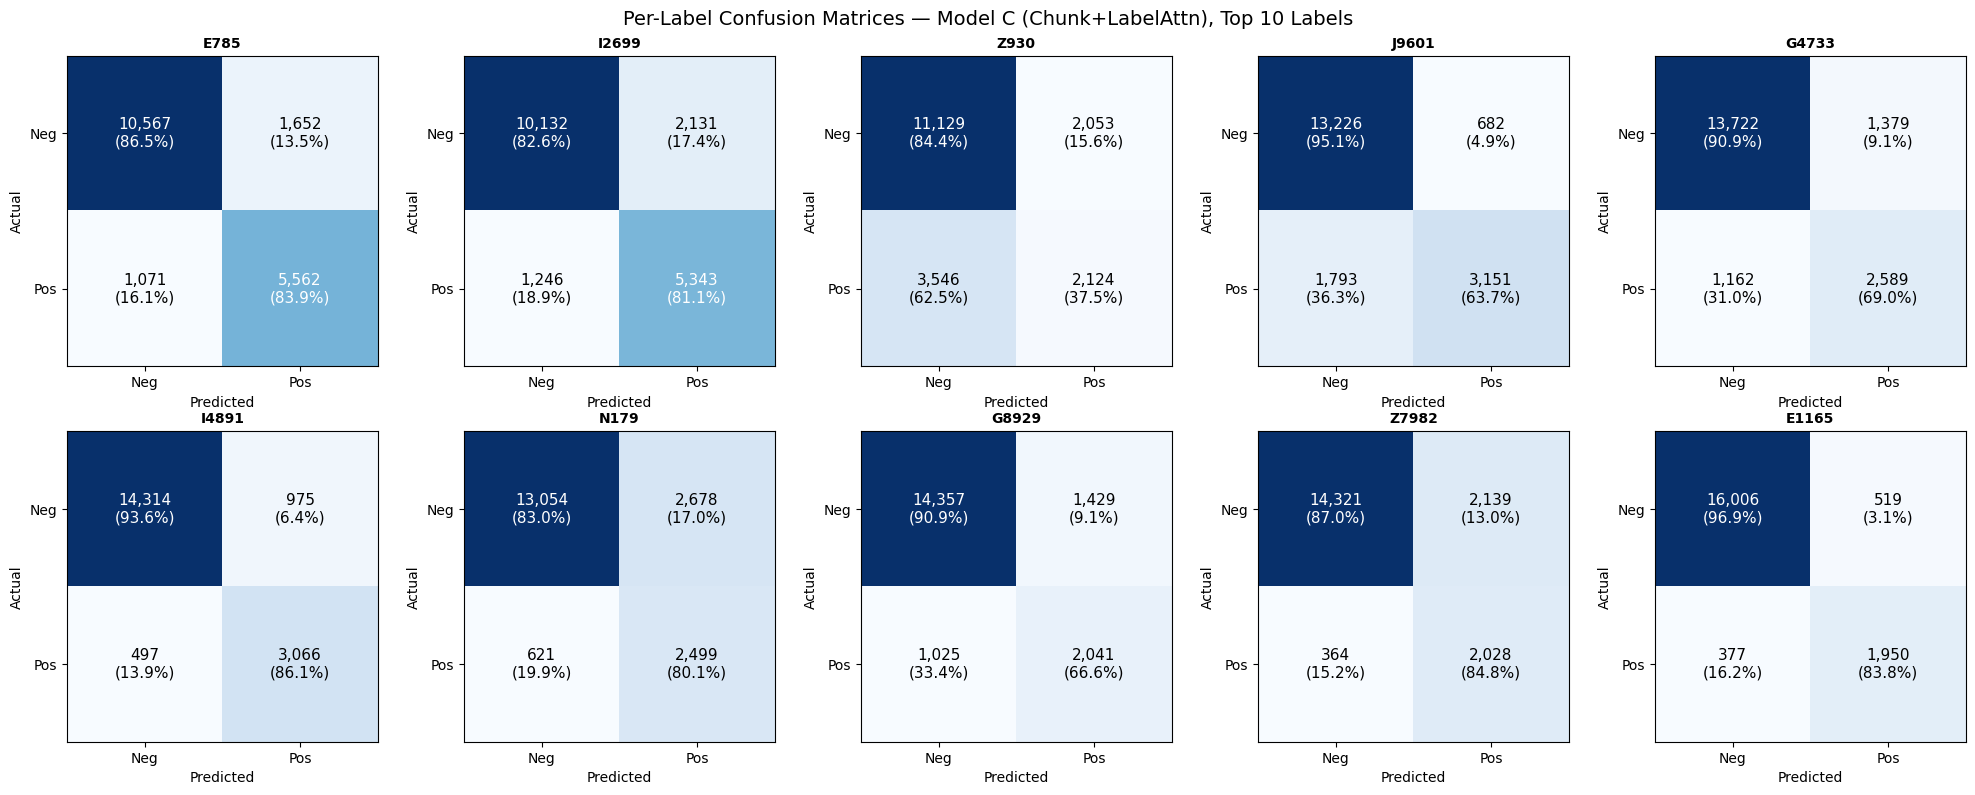


Aggregate Confusion Matrix (all 50 labels):
  TN =    748,263 (79.4%)   FP =     97,230 (10.3%)
  FN =     26,948 (2.9%)   TP =     70,159 (7.4%)


In [ ]:
# Plots confusion matrices for each label.

import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import multilabel_confusion_matrix

DATA_DIR  = Path('../datasets/processed')
MODEL_DIR = Path('../data/models/model_c')
TOP_N = 10

with open(DATA_DIR / 'mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

Y_test  = np.load(DATA_DIR / 'Y_test.npy')

P_test = np.load(MODEL_DIR / 'P_test.npy')

with open(MODEL_DIR / 'test_results.json') as f:
    threshold = json.load(f)['Threshold']
preds_test = (P_test >= threshold).astype(int)

mcm = multilabel_confusion_matrix(Y_test, preds_test)

freq = Y_test.sum(0)
top_idx = np.argsort(freq)[::-1][:TOP_N]

nrows, ncols = 2, TOP_N // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for idx, ax in zip(top_idx, axes.flat):
    cm = mcm[idx]
    ax.imshow(cm, cmap='Blues')
    ax.set_title(vocab[idx], fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
            row_total = cm[r].sum()
            pct = cm[r, c] / row_total * 100 if row_total > 0 else 0
            ax.text(c, r, f'{cm[r, c]:,}\n({pct:.1f}%)', ha='center', va='center', color=color, fontsize=11)

plt.suptitle(f'Per-Label Confusion Matrices — Model C (Chunk+LabelAttn), Top {TOP_N} Labels', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'confusion_matrix_top{TOP_N}.png', dpi=150)
plt.show()

agg = mcm.sum(axis=0)
print(f'\nAggregate Confusion Matrix (all {len(vocab)} labels):')
agg_total = agg.sum()
print(f'  TN = {agg[0,0]:>10,} ({agg[0,0]/agg_total*100:.1f}%)   FP = {agg[0,1]:>10,} ({agg[0,1]/agg_total*100:.1f}%)')
print(f'  FN = {agg[1,0]:>10,} ({agg[1,0]/agg_total*100:.1f}%)   TP = {agg[1,1]:>10,} ({agg[1,1]/agg_total*100:.1f}%)')

## 14. Full 50 Label Confusion Analysis

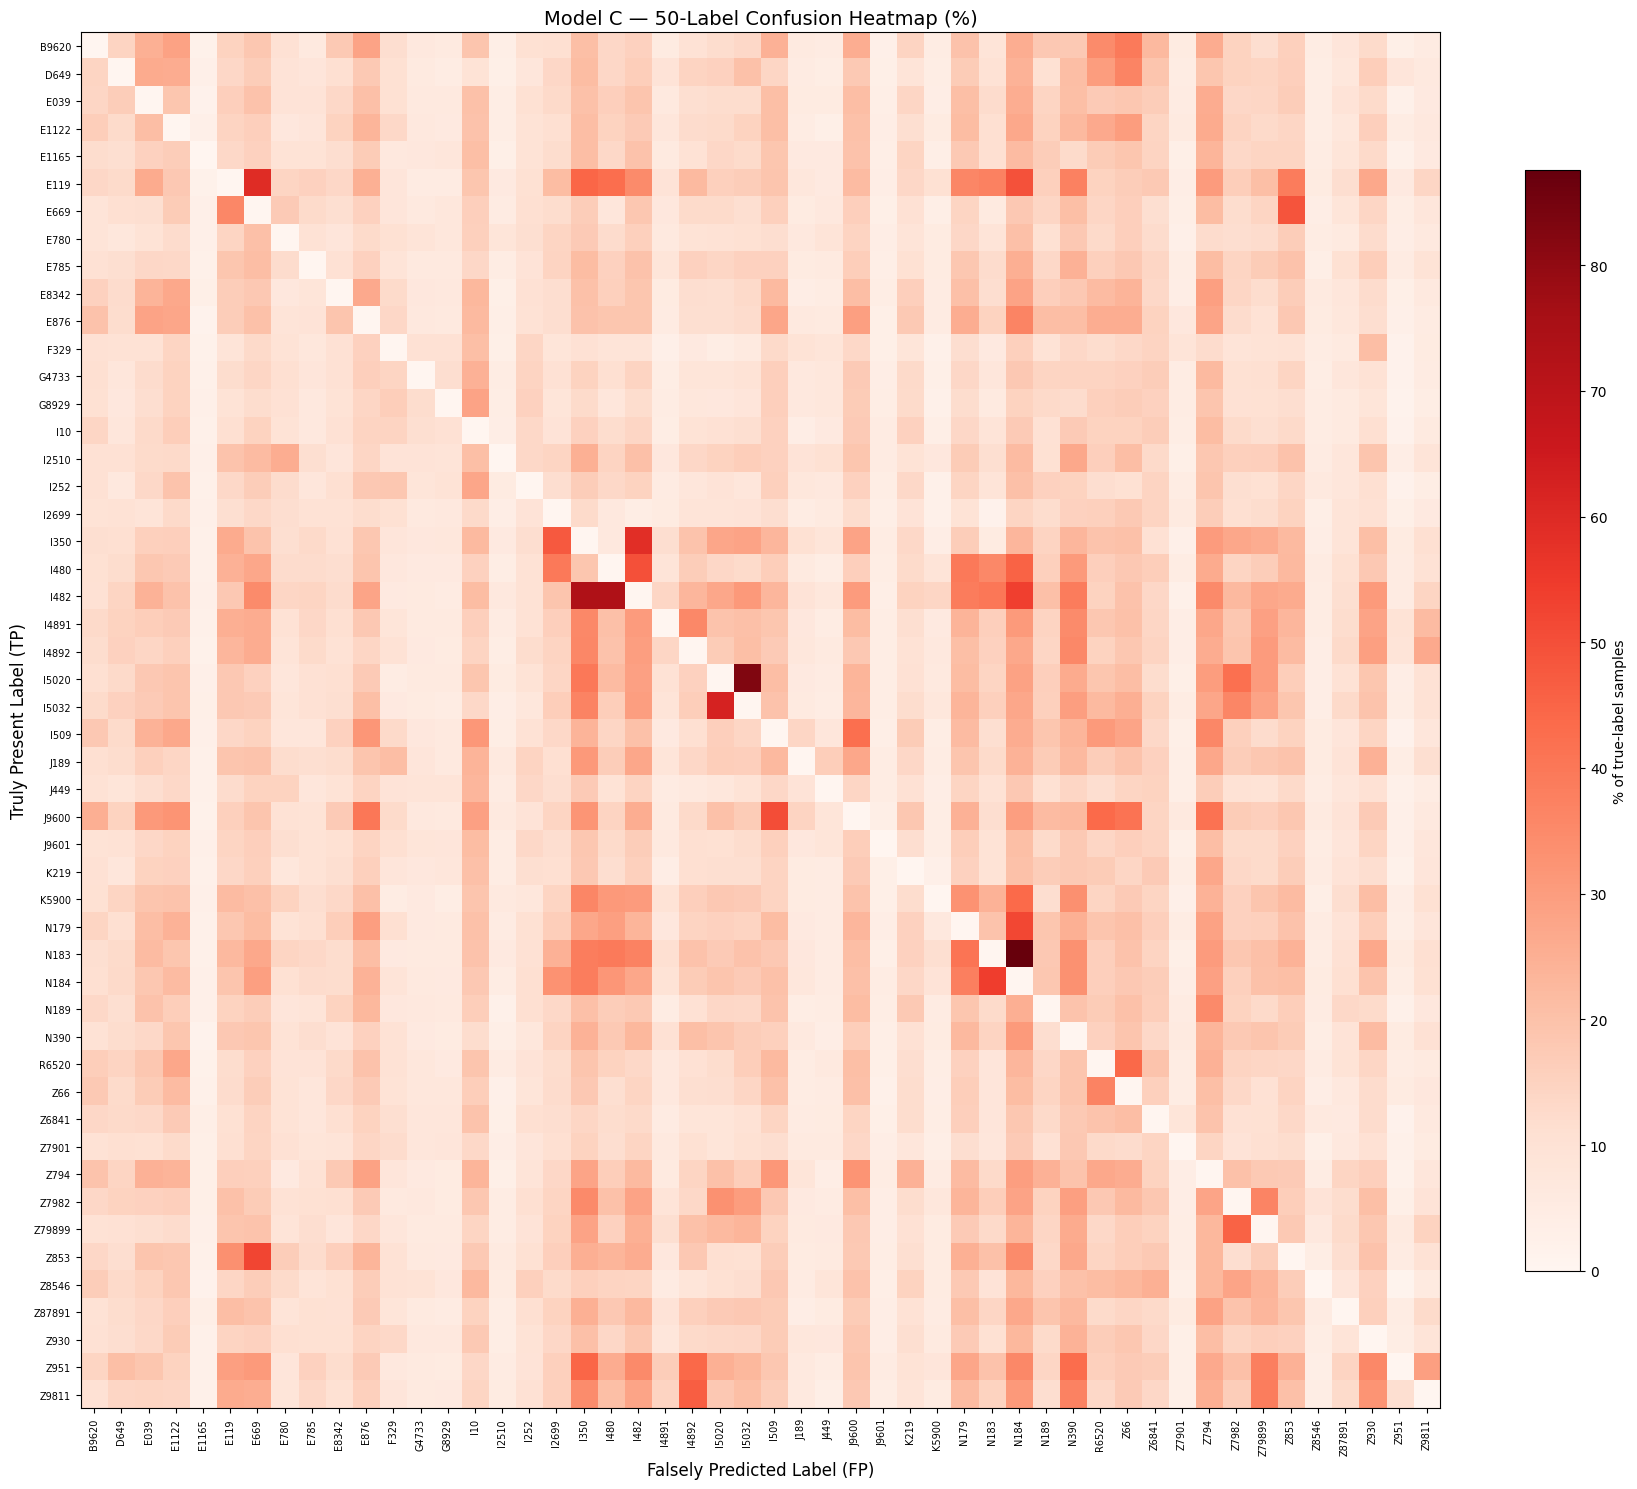


Top 20 most confused label pairs (Model C):
    True Label  →   Falsely Predicted    Count
  --------------------------------------------------
          E785  →                N184    1,669  (25.2% of E785 samples)
          N179  →                N184    1,620  (51.9% of N179 samples)
          E785  →                N390    1,612  (24.3% of E785 samples)
          E785  →                Z794    1,425  (21.5% of E785 samples)
          E785  →                I350    1,409  (21.2% of E785 samples)
          E785  →                E669    1,403  (21.2% of E785 samples)
          Z930  →                N390    1,368  (24.1% of Z930 samples)
          E785  →                Z853    1,315  (19.8% of E785 samples)
          E785  →                I482    1,314  (19.8% of E785 samples)
          Z930  →                N184    1,299  (22.9% of Z930 samples)
         I4891  →               I4892    1,265  (35.5% of I4891 samples)
         I4891  →                I350    1,264  (35.5% of I489

In [ ]:
# Plots confusion matrix for all 50 lables and identifies commonly confused ICD pairs

TOP_PAIRS = 20
n_labels = len(vocab)

fp_mask = (preds_test == 1) & (Y_test == 0)
tp_mask = (Y_test == 1)

label_confusion = tp_mask.astype(int).T @ fp_mask.astype(int)

fig, ax = plt.subplots(figsize=(18, 15))
row_sums = tp_mask.sum(axis=0).reshape(-1, 1)
row_sums = np.where(row_sums == 0, 1, row_sums)
label_confusion_pct = label_confusion / row_sums * 100
im = ax.imshow(label_confusion_pct, cmap='Reds', aspect='auto', interpolation='nearest')
ax.set_xticks(range(n_labels)); ax.set_yticks(range(n_labels))
ax.set_xticklabels(vocab, rotation=90, fontsize=7)
ax.set_yticklabels(vocab, fontsize=7)
ax.set_xlabel('Falsely Predicted Label (FP)', fontsize=12)
ax.set_ylabel('Truly Present Label (TP)', fontsize=12)
ax.set_title(f'Model C — {n_labels}-Label Confusion Heatmap (%)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='% of true-label samples')
plt.tight_layout()
plt.savefig(MODEL_DIR / f'label_confusion_{n_labels}x{n_labels}.png', dpi=150)
plt.show()

np.fill_diagonal(label_confusion, 0)
flat_idx = np.argsort(label_confusion.ravel())[::-1]

print(f'\nTop {TOP_PAIRS} most confused label pairs (Model C):')
print(f'  {"True Label":>12s}  →  {"Falsely Predicted":>18s}  {"Count":>7s}')
print('  ' + '-' * 50)
shown = 0
for fi in flat_idx:
    if shown >= TOP_PAIRS:
        break
    i, j = divmod(fi, n_labels)
    count = label_confusion[i, j]
    if count == 0:
        break
    tp_total = tp_mask[:, i].sum()
    pct = count / tp_total * 100 if tp_total > 0 else 0
    print(f'  {vocab[i]:>12s}  →  {vocab[j]:>18s}  {count:>7,}  ({pct:.1f}% of {vocab[i]} samples)')
    shown += 1